In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import gropt
from helper_utils import *
import gropt
from gropt_diffusion2 import *
from trap_diffusion3 import *

# note need to name file to specify DWI or DTI cause will de-rate refocusing a little 

In [3]:
# ---------------- Choose scenario ----------------
# Options: "Hardware-Limited", "PNS-Limited", "Slew-Rate-Limited"
scenario_demo = "PNS-Limited"
pns_Factor = 0.7 # 0.85 for DWI, 0.7 for DTI
gmax_demo = 0.19 # Siemens software says not to exceed 0.19 T/m 
b_target_demo = 3000 # Target b-value in s/mm^2
mmt_demo = 0# 0: M0-nulled, 1: M1-nulled (in addition to M0)

In [4]:
# Load ASC file and make SAFE params

asc_file_name = ['/Users/ariel/Desktop/MP_GradSys_P034_X60.asc', # for 200/200 System
              '/Users/ariel/Documents/PhD/Projects/asc_files/MP_GradSys_K2309_2250V_951A_XQ_GC04XQ.asc', # for 80/200 System
              '/Users/ariel/Downloads/MP_GPA_K2309_2250V_793A_GC99 (1).asc'] # for 45/200 System


In [5]:
import os

main_path = '../Sequence_Code'
timings_file = os.path.join(main_path, 'diffusion_timing_parameters_Gmax200_slr-ls.mat')
waveforms_file = os.path.join(main_path, 'diffusion_timing_parameters_Gmax200_slr-ls_waveforms.mat')
epi_file  = os.path.join('diffusion_timing_parameters_Gmax200_slr-ls_waveforms_epi_only.npz')

if gmax_demo == 0.19:
    [safe_params, safe_params_cardiac] = gropt.readasc.asc_to_safe(asc_file_name[0])
    grad_mTpm = 200
    idx = 0
elif gmax_demo == 0.08:
    [safe_params, safe_params_cardiac] = gropt.readasc.asc_to_safe(asc_file_name[1])
    grad_mTpm = 80
    idx = 0
elif gmax_demo == 0.045:
    [safe_params, safe_params_cardiac] = gropt.readasc.asc_to_safe(asc_file_name[1])
    grad_mTpm = 45
    idx = 0
print(grad_mTpm)

epi = np.load(epi_file)




200


In [6]:
import numpy as np
import gropt
from scipy.io import loadmat
import matplotlib.pyplot as plt
import gc

# ---------------- General Setup ----------------
xlabel_font = 30
ylabel_font= 30
xtick_font= 27
ytick_font= 27
title_font= 32
legend_font= 22

if gmax_demo == 0.19:
    [safe_params, safe_params_cardiac] = gropt.readasc.asc_to_safe(asc_file_name[0])
    grad_mTpm = 200
elif gmax_demo == 0.08:
    [safe_params, safe_params_cardiac] = gropt.readasc.asc_to_safe(asc_file_name[0])
    grad_mTpm = 80
elif gmax_demo == 0.045:
    [safe_params, safe_params_cardiac] = gropt.readasc.asc_to_safe(asc_file_name[0])
    grad_mTpm = 45

if b_target_demo == 1000:
    xMax = 100
elif b_target_demo == 3000:
    xMax = 120

else:
    xMax = 80

# Load timings for System
timings_data = loadmat(timings_file)
T_90_demo = timings_data['rf_90_duration'][0][0] - timings_data['rf_90_rfCenterInclDelay'][0][0] + timings_data['nav_dur'][0][0]
T_180_demo = timings_data['rf_180_duration'][0][0] 
rf_180_rfCenterInclDelay_demo = timings_data['rf_180_rfCenterInclDelay'][0][0]
sys = timings_data['sys']
dt = 1e-5
print('RF 90 duration is', T_90_demo*1e3,'ms')


T_readout_demo = timings_data['timeToTE'][0][0]
print('Readout time is ', T_readout_demo*1e3, 'ms')
print('Rf 180 duration is ', T_180_demo*1e3, 'ms')
dt = 1e-5

do_plot = True
do_gropt = True

custom_vec_mode = True #True


# Set scenario-specific parameters
if scenario_demo == "Hardware-Limited":
    smax_demo = 200
    pns_thresh_demo = None
    cns_thresh_demo = None
    safe_params_demo = None
    safe_params_cardiac_demo = None
elif scenario_demo == "PNS-Limited":
    smax_demo = 200
    pns_thresh_demo = pns_Factor#0.90#60 seems ok 0.9 for vec 
    cns_thresh_demo = pns_Factor#0.90#60 seems ok 0.9 for vec 
    safe_params_demo = safe_params  # replace with actual SAFE params if available
    safe_params_cardiac_demo = safe_params_cardiac  # replace with actual SAFE params if available
    smax_range = np.concatenate(([200], np.arange(120, 20, -2)))
    gmax_range = np.arange(gmax_demo*1e3, 20, -2)*1e-3
elif scenario_demo == "Slew-Rate-Limited":
    smax_demo = 40
    pns_thresh_demo =pns_Factor
    cns_thresh_demo = pns_Factor
    safe_params_demo = safe_params
    safe_params_cardiac_demo = safe_params_cardiac
    smax_range = [40]
    gmax_range = np.arange(gmax_demo*1e3, 20, -2)*1e-3
else:
    raise ValueError(f"Unknown scenario: {scenario_demo}")


print(scenario_demo, pns_Factor)

# ---------------- Optimize waveform ----------------
if do_gropt:
    # print input params
    [last_good_TE, last_good_result, last_good_bval, final_good,
    last_good_solve_time, gparams_final,
    stim_vec_pns_final, stim_vec_cns_final, track_gropt] = optimize_diffusion_waveform_minTE(
        T_90_demo, T_180_demo, T_readout_demo,
        25e-3, 85e-3, 200e-6, b_target_demo+1,
        smax=np.max(smax_demo), gmax=np.max(gmax_demo),
        custom_vec = custom_vec_mode,
        pns_max=pns_thresh_demo,
        cns_max=cns_thresh_demo,
        safe_params=safe_params_demo,
        safe_params_cardiac=safe_params_cardiac_demo,
        tol=1e-6, max_iter=50, mmt=mmt_demo, 
        timings_path = timings_file,
        waveforms_path = waveforms_file,
        iteration_logging = True,
    )

    g = last_good_result
    t = np.arange(len(g)) * gparams_final.dt

    pre_180_idx = np.argmin(abs(t - last_good_TE/2))
    g_pre = g[:pre_180_idx] 
    g_post = g[pre_180_idx:] 
    print('||g_left||$^2$ = ', np.sum(np.abs(g_pre)**2) * gparams_final.dt)
    print('||g_right||$^2$ = ', np.sum(np.abs(g_post)**2) * gparams_final.dt)
    print('Ratio  ||g_left||$^2$ / ||g_right||$^2$ = ', np.sum(np.abs(g_pre)**2) / np.sum(np.abs(g_post)**2))

    print(f"[{scenario_demo}] Result: TE = {last_good_TE*1e3:.2f} ms, "
        f"bval = {last_good_bval:.1f} s/mm², Solve time = {last_good_solve_time:.1f} s, Final good: {final_good}")


    if pns_thresh_demo is None:
        pns_lim_plot = np.inf
    else:
        pns_lim_plot = pns_thresh_demo

    if do_plot:
        
        
        
        plot_safe_full_invert(
                last_good_result,
                gparams_final,
                safe_params_demo,
                safe_params_cardiac_demo,
                plot_gradient = True, plot_slew = True,max_pns = pns_lim_plot*100, max_cns = pns_lim_plot*100,
                plot_cns=True,
                smax=smax_demo,dark_mode=False,
                stim_vec=stim_vec_pns_final,line_width = 5,
                stim_vec_cns = stim_vec_cns_final,
                plot_moments=True,xMax = xMax,
                T_readout=T_readout_demo*1e3,
                xlabel_font=xlabel_font, ylabel_font=ylabel_font, xtick_font=xtick_font, ytick_font=ytick_font,
                title_font=title_font, legend_font=legend_font,    epi = epi,
                # remove TE from below save naame
                save_path =  f'pulseq_v2_gropt_{scenario_demo}_gmax{gmax_demo*1e3:.0f}_smax{smax_demo}_mmt{mmt_demo}_b{b_target_demo}_TE{last_good_TE*1e3:.1f}.svg',
            )
        
       

# ---------------- Compute Min TE trapezoid waveform ----------------
if mmt_demo == 2:
    mmt_demo_in = -2
else:
    mmt_demo_in = mmt_demo
minTE_obj = GetMinTE_Trap(
    targetBval=b_target_demo,
    T_90=T_90_demo,
    T_180=T_180_demo,
    T_readout=T_readout_demo,
    pnsThresh=pns_thresh_demo if pns_thresh_demo is not None else np.inf,
    safe_params=safe_params_demo,
    safe_params_cardiac=safe_params_cardiac_demo,
    gmaxRange=gmax_range,
    smaxRange=smax_range,
    rf_180_rfCenterInclDelay=rf_180_rfCenterInclDelay_demo,
    dt=dt,
    maxTE=300e-3,
    custom_stim_vec = False,
    mmt=mmt_demo_in,

)

TE_trap, g_waveform_trap, t_array, bval_trap, timings_trap = minTE_obj.compute_binary()
print(f"[{scenario_demo}] Trapezoid TE = {TE_trap*1e3:.2f} ms, bval = {bval_trap:.1f} s/mm²")

# ---------------- Optional: Plot SAFE ----------------
do_plot = True
if do_plot:
    #stim_vec = 0.75 * np.ones_like(g_waveform_trap)

    plot_safe_full_invert(
        g_waveform_trap,
        minTE_obj,
        safe_params_demo,
        safe_params_cardiac_demo,
        plot_gradient = True, plot_slew = True,max_pns = pns_thresh_demo*100, max_cns = pns_thresh_demo*100,
        plot_cns=True,
        smax=smax_demo,dark_mode = False,
        stim_vec=timings_trap['pns_thresh'],
        stim_vec_cns =timings_trap['cns_thresh'],
        plot_moments=False,
        T_readout=T_readout_demo*1e3,
        save_path =  f'pulseq_v2_trap_{scenario_demo}_gmax{gmax_demo*1e3:.0f}_smax{smax_demo}_mmt{mmt_demo}_b{b_target_demo}_TE{TE_trap*1e3:.1f}.svg',
        xlabel_font=xlabel_font, ylabel_font=ylabel_font, xtick_font=xtick_font, ytick_font=ytick_font,
        title_font=title_font, legend_font=legend_font,line_width = 5,
        xMax = xMax,
        epi = epi,
    )
    plt.show()


print('Max Gradient Trap is ', np.max(np.abs(g_waveform_trap))*1e3, 'mT/m')
# ---------------- Cleanup ----------------
gc.collect()


RF 90 duration is 2.905 ms
Readout time is  13.793999999999999 ms
Rf 180 duration is  6.840000000000001 ms
PNS-Limited 0.7
Optimizing diffusion waveform for min TE between 25.00 ms and 85.00 ms
Iter 1: TE=60.70 ms | Final Good=True | b=3000.01 | Solve=1724.09 ms
[2026-02-12 15:00:34.103] [error] NaN detected in Xhat at iteration 891. Stopping solver.
Iter 2: TE=48.55 ms | Final Good=False | b=116598539662671764172751244137208721827429592647544073492802863224074440711917585055607362393530718456746785169119931866806383441463116291292135675566821267779661968187239568121493258317209411044200393137344951947097145059466813596590486382398843942994203178468114432.00 | Solve=313.86 ms
Iter 3: TE=54.63 ms | Final Good=True | b=3000.03 | Solve=1507.72 ms
[2026-02-12 15:00:35.987] [error] NaN detected in Xhat at iteration 998. Stopping solver.
Iter 4: TE=51.59 ms | Final Good=False | b=31743343255876336148395525207068758552627545469438526842406086764921498370056148747061940828407842602390238296536

KeyboardInterrupt: 

In [ ]:
T_180_demo

np.float64(0.006840000000000001)

In [ ]:
import numpy as np

save_filename = f'pulseq_diffusion_waveform_params_{scenario_demo}_b{b_target_demo}_g{gmax_demo}_m{mmt_demo}.npz'

np.savez(
    save_filename,
    # General info
    scenario=scenario_demo,
    dt=dt,
    mmt=mmt_demo,
    b_target=b_target_demo,
    gmax_demo=gmax_demo,
    smax_demo=smax_demo,

    # GRopt results (arrays only, skip gparams_final)
    last_good_TE=last_good_TE if do_gropt else np.nan,
    last_good_result=last_good_result if do_gropt else None,
    last_good_bval=last_good_bval if do_gropt else np.nan,
    stim_vec_pns_final=stim_vec_pns_final if do_gropt else None,
    stim_vec_cns_final=stim_vec_cns_final if do_gropt else None,
    dt_gropt=gparams_final.dt if do_gropt else np.nan,  

    # Trap results
    TE_trap=TE_trap,
    g_waveform_trap=g_waveform_trap,
    t_array=t_array,
    bval_trap=bval_trap,
    timings_trap=timings_trap,
    dt_trap = dt
)

print(f"Parameters saved to {save_filename}")

Parameters saved to pulseq_diffusion_waveform_params_PNS-Limited_b3000_g0.19_m0.npz


In [ ]:
timings_data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'Ny_meas', 'gx', 'gxPre', 'gz', 'gz_180', 'nNav', 'nav_dur', 'rf_180_duration', 'rf_180_rfCenterInclDelay', 'rf_90_duration', 'rf_90_rfCenterInclDelay', 'sys', 'timeToTE'])

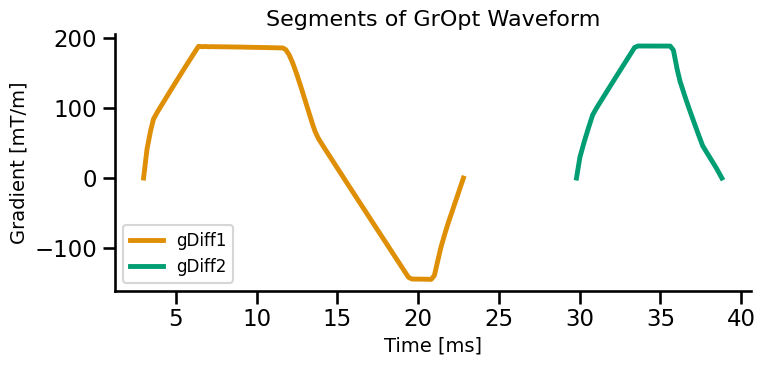

Saved gDiffs to ../Sequence_Code/diffusion_gropt_parameters_m0_gmax200_b3000_slr-ls_pns70_vec.mat
../Sequence_Code/diffusion_trap_parameters_m0_gmax200_bval3000_slr-ls_pns70_vec.mat
diffusion_trap_parameters_m0_gmax200_bval3000_slr-ls_pns70_vec


In [ ]:
import os
# -----------------------------------------------------------
# ---------------- Save Stim-CODE Waveforms  ----------------
# -----------------------------------------------------------
save_name = f'diffusion_gropt_parameters_m{mmt_demo}_gmax{grad_mTpm}_b{b_target_demo}_slr-ls_pns{int(pns_thresh_demo*100)}.mat'
if custom_vec_mode:
    save_name = f'diffusion_gropt_parameters_m{mmt_demo}_gmax{grad_mTpm}_b{b_target_demo}_slr-ls_pns{int(pns_thresh_demo*100)}_vec.mat'

# Split gradients and interpolate to gradient raster with output ready to add to sequence as two seperate arrays
gDiffs = process_gradient_waveform(last_good_result, gparams_final.dt,
                                    1e-5, 
                                    last_good_TE, 
                                    save_path=os.path.join(main_path,save_name), 
                                    threshold=1e-4)


# -----------------------------------------------------------
# ---------------- Save Mono or Bipolar Waveforms  ----------------
# -----------------------------------------------------------

# save timings for formatting traps
save_name = f'diffusion_trap_parameters_m{mmt_demo}_gmax{grad_mTpm}_bval{b_target_demo}_slr-ls_pns{int(pns_thresh_demo*100)}'

if custom_vec_mode:
    save_name = f'diffusion_trap_parameters_m{mmt_demo}_gmax{grad_mTpm}_bval{b_target_demo}_slr-ls_pns{int(pns_thresh_demo*100)}_vec'


timings_save = {
    'TE': TE_trap,
    'rise_time': timings_trap['rise_time'],
    'fall_time': timings_trap['fall_time'],
    'flat_time': timings_trap['flat_time'],
    'pns_thresh': minTE_obj.pnsThresh,
    'amplitude': np.max(g_waveform_trap),
}
# .mat save
import scipy.io as sio
sio.savemat(f"{main_path}/{save_name}.mat", timings_save)

print(f"{main_path}/{save_name}.mat")
print(save_name)


In [ ]:
import numpy as np

dirs = np.array([
    [-0.505602,  0.612022, -0.608109],
    [-0.747603,  0.386488, -0.540109],
    [ 0.863637,  0.208654,  0.458906],
    [ 0.980126,  0.138091,  0.142423],
    [ 0.554302, -0.269706,  0.787406],
    [-0.304976,  0.475468, -0.825178],
    [-0.124327,  0.697366,  0.705849],
    [-0.747884,  0.663261,  0.027458],
    [-0.189884,  0.148707,  0.970479],
    [-0.159778,  0.728171, -0.666512],
    [-0.144324,  0.977406, -0.154430],
    [ 0.626280,  0.316492,  0.712465],
    [-0.213032,  0.871169,  0.442359],
    [-0.463964,  0.673838,  0.575047],
    [-0.436977, -0.127876,  0.890336],
    [-0.537773,  0.800297,  0.265188],
    [ 0.780540,  0.621304, -0.068831],
    [ 0.461319,  0.687785,  0.560478],
    [ 0.980696, -0.018559, -0.194656],
    [-0.495250,  0.863797, -0.092642],
    [ 0.339283,  0.432451, -0.835388],
    [-0.739904,  0.558849,  0.374474],
    [-0.271517,  0.952538,  0.137660],
    [-0.862593,  0.454693, -0.221782],
    [-0.002539,  0.426456,  0.904505],
    [ 0.506039,  0.611980, -0.607787],
    [-0.978996,  0.182033, -0.091816],
    [ 0.604860,  0.732140, -0.313235],
    [ 0.365231,  0.889309,  0.275203],
    [ 0.648099,  0.725298,  0.232184],
    [-0.493345,  0.188235,  0.849222],
    [ 0.710597,  0.513404,  0.481112],
    [ 0.126630,  0.856427,  0.500498],
    [ 0.145616,  0.130335,  0.980718],
    [ 0.873990,  0.446310,  0.192221],
    [ 0.053752,  0.980472,  0.189171],
    [ 0.354860,  0.384649,  0.852127],
    [ 0.876325,  0.152391, -0.456980],
    [ 0.323578,  0.859736, -0.395159],
    [ 0.191140,  0.975879, -0.105482],
    [ 0.490728,  0.870583, -0.035666],
    [ 0.904374, -0.126457,  0.407573],
    [-0.867797,  0.218237,  0.446431],
    [ 0.735538, -0.017931,  0.677246],
    [-0.655213,  0.682558, -0.323744],
    [-0.333432,  0.468433,  0.818165],
    [ 0.467251,  0.052575,  0.882560],
    [ 0.227426, -0.187534,  0.955567],
    [ 0.003879,  0.901359, -0.433055],
    [ 0.651021,  0.311461, -0.692217],
    [-0.348927,  0.845902, -0.403361],
    [ 0.184449,  0.711765, -0.677768],
    [ 0.016495,  0.480727, -0.876715],
    [ 0.207640,  0.639865,  0.739904],
    [ 0.935624,  0.321853, -0.144981],
    [-0.106283, -0.171771,  0.979387],
    [-0.909516,  0.387207,  0.151168],
    [-0.654229,  0.392609,  0.646407],
    [-0.724142,  0.023621,  0.689246],
    [ 0.780781,  0.468697, -0.413163],
])

# take every other direciton

dirs_half = dirs[::2]

Subset A min angle: 19.66 deg
Subset B min angle: 17.99 deg


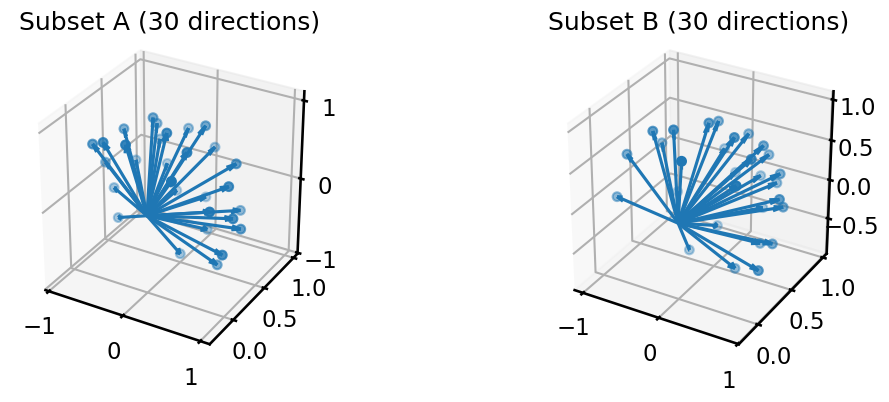

Subset A angle distribution (degrees):
19.660488375505516 77.95020463800356 160.9300982897764
Subset B angle distribution (degrees):
17.993658003778922 70.98353496119579 161.26937162459967


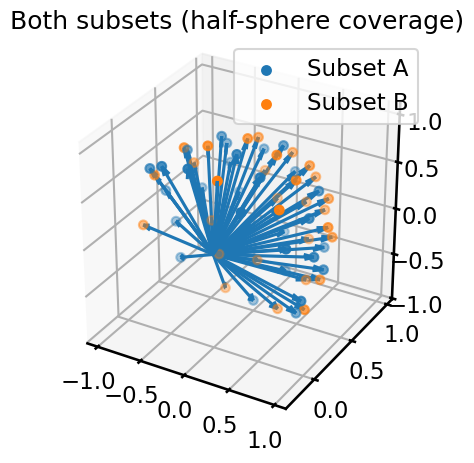

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# INPUT: directions (60 x 3 numpy array)
# -------------------------------------------------
# dirs = np.array([...])  # your 60x3 array here

assert dirs.shape == (60, 3), "dirs must be shape (60, 3)"

# -------------------------------------------------
# Normalize
# -------------------------------------------------
dirs = dirs / np.linalg.norm(dirs, axis=1, keepdims=True)
dirs = np.round(dirs, decimals=6)  # round to avoid numerical issues

# -------------------------------------------------
# Step 1: seed (top of hemisphere)
# -------------------------------------------------
seed_idx = np.argmax(dirs[:, 2])

subsetA = [seed_idx]
remaining = list(set(range(60)) - set(subsetA))

# -------------------------------------------------
# Step 2: farthest-point sampling for subset A
# -------------------------------------------------
while len(subsetA) < 30:
    # cosine similarity to existing subset
    dots = dirs[remaining] @ dirs[subsetA].T

    # closest existing direction
    min_dots = np.max(dots, axis=1)

    # pick farthest candidate
    idx = np.argmin(min_dots)

    subsetA.append(remaining[idx])
    remaining.pop(idx)

subsetA = np.array(subsetA)
subsetB = np.array(remaining)

# -------------------------------------------------
# Step 3: angular distance statistics
# -------------------------------------------------
def angular_matrix(X):
    dots = np.clip(X @ X.T, -1.0, 1.0)
    ang = np.degrees(np.arccos(dots))
    np.fill_diagonal(ang, np.nan)
    return ang

A = dirs[subsetA]
B = dirs[subsetB]

angA = angular_matrix(A)
angB = angular_matrix(B)

print(f"Subset A min angle: {np.nanmin(angA):.2f} deg")
print(f"Subset B min angle: {np.nanmin(angB):.2f} deg")

# -------------------------------------------------
# Step 4: Visualization
# -------------------------------------------------
fig = plt.figure(figsize=(12, 4))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(A[:, 0], A[:, 1], A[:, 2], s=40)
ax1.set_title("Subset A (30 directions)")
ax1.set_box_aspect([1, 1, 1])
ax1.grid(True)

for i in range(len(A)):
    ax1.quiver(0, 0, 0, A[i, 0], A[i, 1], A[i, 2], arrow_length_ratio=0.1)


ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(B[:, 0], B[:, 1], B[:, 2], s=40)
ax2.set_title("Subset B (30 directions)")
ax2.set_box_aspect([1, 1, 1])
ax2.grid(True)
for i in range(len(B)):
    ax2.quiver(0, 0, 0, B[i, 0], B[i, 1], B[i, 2], arrow_length_ratio=0.1)


plt.tight_layout()
plt.show()

# -------------------------------------------------
# Step 5: overlay both subsets
# -------------------------------------------------
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(A[:, 0], A[:, 1], A[:, 2], s=40, label="Subset A")
ax.scatter(B[:, 0], B[:, 1], B[:, 2], s=40, label="Subset B")

# plot as vector too
for i in range(len(A)):
    ax.quiver(0, 0, 0, A[i, 0], A[i, 1], A[i, 2], arrow_length_ratio=0.1)
for i in range(len(B)):
    ax.quiver(0, 0, 0, B[i, 0], B[i, 1], B[i, 2], arrow_length_ratio=0.1)

ax.set_box_aspect([1, 1, 1])
ax.legend()
ax.set_title("Both subsets (half-sphere coverage)")
ax.grid(True)

# print each subsets angle distribution 
print("Subset A angle distribution (degrees):")
print(np.nanmin(angA), np.nanmean(angA), np.nanmax(angA))
print("Subset B angle distribution (degrees):")
print(np.nanmin(angB), np.nanmean(angB), np.nanmax(angB))

plt.show()


# append [0,0,0] to beginning of subset then save as savemat("diffusion_directions_DTI.mat", {
  #  "b1000": group A,
  #  "b3000": group B 


from scipy.io import savemat
dirs_b1000 = np.vstack(([0, 0, 0], A))
dirs_b3000 = np.vstack(([0, 0, 0], B))
savemat("../Sequence_Code/diffusion_directions_DTI.mat", {
    "b1000": dirs_b1000,
    "b3000": dirs_b3000
})

In [ ]:
print(dirs_b1000 )

[[ 0.        0.        0.      ]
 [ 0.145616  0.130335  0.980718]
 [ 0.016495  0.480727 -0.876715]
 [-0.909516  0.387207  0.151168]
 [ 0.980696 -0.018559 -0.194656]
 [ 0.053752  0.980472  0.189171]
 [ 0.710597  0.513404  0.481112]
 [ 0.60486   0.73214  -0.313235]
 [-0.747603  0.386488 -0.540109]
 [-0.463964  0.673838  0.575047]
 [-0.724142  0.023621  0.689246]
 [-0.49525   0.863797 -0.092642]
 [ 0.904374 -0.126457  0.407573]
 [ 0.003879  0.901359 -0.433055]
 [ 0.651021  0.311461 -0.692217]
 [ 0.20764   0.639865  0.739904]
 [ 0.554302 -0.269706  0.787406]
 [-0.106283 -0.171771  0.979387]
 [ 0.980126  0.138091  0.142423]
 [ 0.184449  0.711765 -0.677768]
 [-0.654229  0.392609  0.646407]
 [-0.213032  0.871169  0.442359]
 [-0.436977 -0.127876  0.890336]
 [-0.862593  0.454693 -0.221782]
 [ 0.467251  0.052575  0.88256 ]
 [ 0.935623  0.321853 -0.144981]
 [-0.333432  0.468433  0.818165]
 [-0.348927  0.845902 -0.403361]
 [-0.747884  0.663261  0.027458]
 [-0.537773  0.800297  0.265188]
 [ 0.86363